<a href="https://colab.research.google.com/github/samridhi25445/ChatGPT-Analysis/blob/main/ChatGPT_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nltk

In [29]:
# Importing the dataset
df = pd.read_csv('/chatgpt_reviews.csv')
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [9]:
# Getting an idea abput duplicate rows
df.duplicated().sum()

np.int64(2511)

In [10]:
#np.int64(2511) means that there are 2511 rows in the dataset.

In [14]:
# Dropping the duplicate data
df = df.drop_duplicates()

# Getting an idea about duplicate rows
df.duplicated().sum()

np.int64(0)

In [15]:
#np.int64(0) means that there are 0 rows in the dataset.

In [16]:
# Getting an idea about null values
df.isnull().sum().any()

np.True_

In [ ]:
# np.True_ means that there are NULL values in the dataset

In [17]:
#Getting an idea about the column wise sum of NULL values
df.isnull().sum()

,0
Review Id,0
Review,6
Ratings,0
Review Date,0


In [18]:
# Getting an idea about the shape of the dataset
print('Shape :', df.shape)
print('Number of rows :', df.shape[0])
print('Number of columns :', df.shape[1])

Shape : (194216, 4)
Number of rows : 194216
Number of columns : 4


In [21]:
# Dropping the rows with the NULL values
df=df.dropna()

# Checking the NULL Values in the dataset
df.isnull().sum() #gives the columns with null values
df.isnull().sum().any() #give True or False

np.False_

In [22]:
# Getting an idea of data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194210 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    194210 non-null  object
 1   Review       194210 non-null  object
 2   Ratings      194210 non-null  int64 
 3   Review Date  194210 non-null  object
dtypes: int64(1), object(3)
memory usage: 7.4+ MB


In [23]:
# Converting the 'Review Date' column to datetime format
df['Review Date'] = pd.to_datetime(df['Review Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194210 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Review Id    194210 non-null  object        
 1   Review       194210 non-null  object        
 2   Ratings      194210 non-null  int64         
 3   Review Date  194210 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.4+ MB


In [30]:
# Getting an idea about the range of values in 'Ratings'
print(f"Minimum Value: {df['Ratings'].min()}")
print(f"Maximum Value: {df['Ratings'].max()}")

Minimum Value: 1
Maximum Value: 5


In [27]:
# 2. Sentiment Analysis
# ------------------------------------------
# Classify sentiment based on Ratings and TextBlob Polarity
def get_text_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0.1:
        return 'Positive'
    elif analysis.sentiment.polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

In [31]:
from textblob import TextBlob

# Assign sentiment category based on user ratings
def get_rating_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Ratings'].apply(get_rating_sentiment)
df['Text_Polarity'] = df['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

print("\n=== Sentiment Distribution ===")
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)


=== Sentiment Distribution ===
Sentiment
Positive    173112
Negative     15458
Neutral       8157
Name: count, dtype: int64


/tmp/ipykernel_533/2043918014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


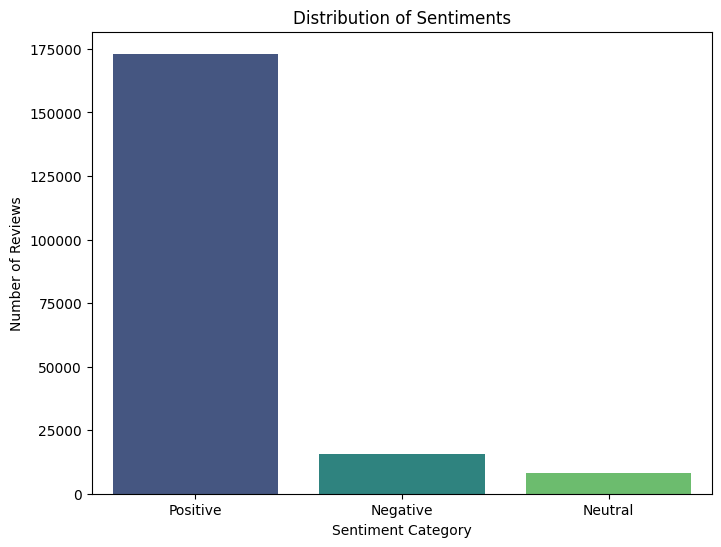

In [37]:
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

/tmp/ipykernel_533/1416684567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette=['g', 'orange', 'r'], order=['Positive', 'Neutral', 'Negative'])


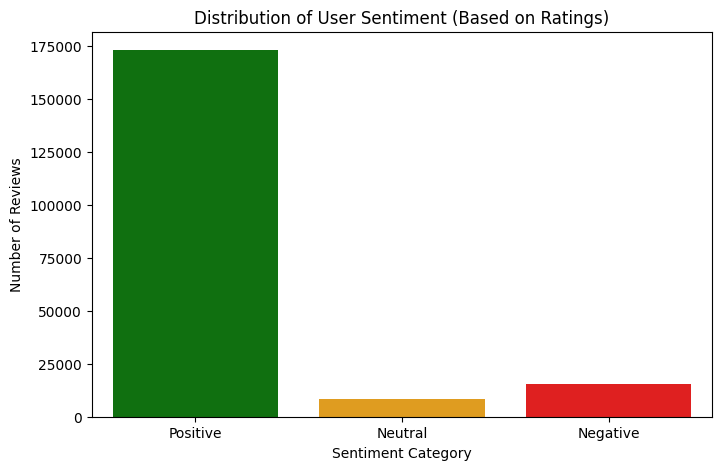

In [32]:
# Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', palette=['g', 'orange', 'r'], order=['Positive', 'Neutral', 'Negative'])
plt.title('Distribution of User Sentiment (Based on Ratings)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

In [33]:
# 3. Issue Identification (Negative Reviews)
# ------------------------------------------
# Extract negative reviews
negative_reviews = df[df['Sentiment'] == 'Negative']['Review'].str.lower()

# Define common key issue categories
issue_keywords = {
    'Network/Connection': ['network', 'connection', 'internet', 'offline', 'error'],
    'Login/Account': ['login', 'log in', 'account', 'sign in', 'password'],
    'Crash/Freeze': ['crash', 'freeze', 'bug', 'glitch', 'stuck', 'slow'],
    'Limits/Pricing': ['limit', 'message limit', 'subscription', 'paid', 'money', 'cost'],
    'Accuracy/Hallucination': ['wrong', 'incorrect', 'false', 'lies', 'dumb', 'stupid']
}

In [34]:
# Categorize common negative issues
issue_counts = {}
for category, keywords in issue_keywords.items():
    pattern = '|'.join(keywords)
    issue_counts[category] = negative_reviews.str.contains(pattern, na=False).sum()

issue_df = pd.DataFrame(list(issue_counts.items()), columns=['Issue Category', 'Frequency']).sort_values(by='Frequency', ascending=False)

print("\n=== Common Issues in Negative Reviews ===")
print(issue_df)


=== Common Issues in Negative Reviews ===
           Issue Category  Frequency
1           Login/Account       1452
0      Network/Connection       1092
4  Accuracy/Hallucination       1004
3          Limits/Pricing        830
2            Crash/Freeze        733


/tmp/ipykernel_533/1767845493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=issue_df, x='Frequency', y='Issue Category', palette='Reds_r')


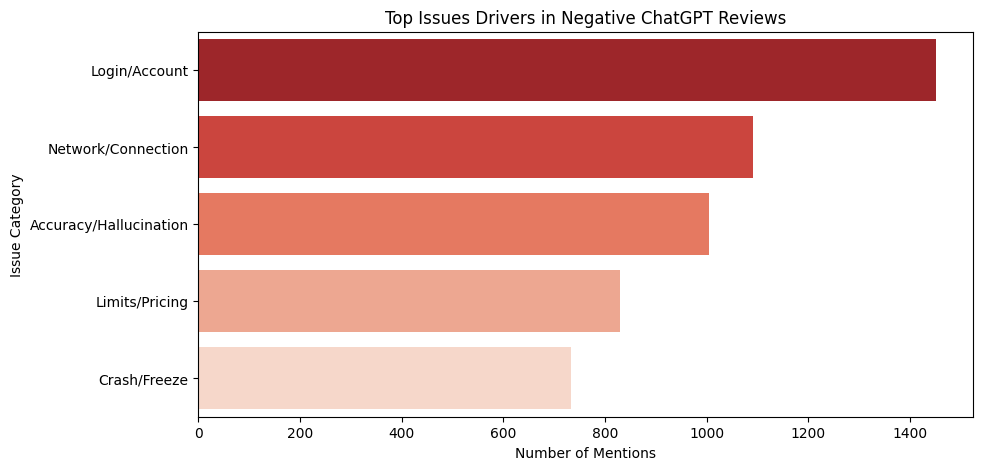

In [35]:
# Visualize Issues
plt.figure(figsize=(10, 5))
sns.barplot(data=issue_df, x='Frequency', y='Issue Category', palette='Reds_r')
plt.title('Top Issues Drivers in Negative ChatGPT Reviews')
plt.xlabel('Number of Mentions')
plt.ylabel('Issue Category')
plt.show()

In [38]:
# 4. Time-Series Analysis
# ------------------------------------------
# Aggregate reviews by Month/Year
# Ensure 'Review Date' is in datetime format
df['Review Date'] = pd.to_datetime(df['Review Date'])
df['YearMonth'] = df['Review Date'].dt.to_period('M')

monthly_sentiment = df.groupby(['YearMonth', 'Sentiment']).size().unstack(fill_value=0)
monthly_ratings = df.groupby('YearMonth')['Ratings'].mean()

In [ ]:
# Plotting monthly sentiment
monthly_sentiment.plot(figsize=(12, 6), title='Monthly Sentiment Distribution Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

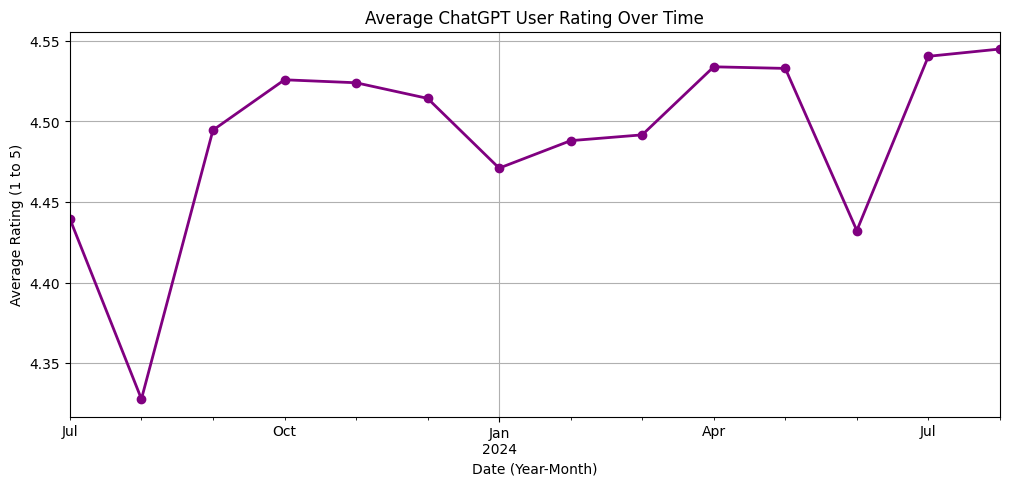

In [39]:
# Plot Average Rating Over Time
plt.figure(figsize=(12, 5))
monthly_ratings.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Average ChatGPT User Rating Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Average Rating (1 to 5)')
plt.grid(True)
plt.show()

<Figure size 1200x600 with 0 Axes>

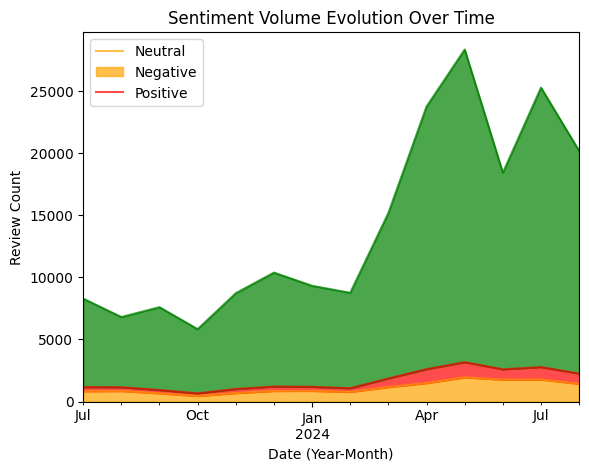

In [40]:
# Plot Sentiment Breakdown Over Time
plt.figure(figsize=(12, 6))
monthly_sentiment.plot(kind='area', stacked=True, color=['orange', 'red', 'green'], alpha=0.7)
plt.title('Sentiment Volume Evolution Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Review Count')
plt.legend(['Neutral', 'Negative', 'Positive'], loc='upper left')
plt.show()